**Yu-gi-oh Forecast**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#read from dataset
df = pd.read_csv("yugioh_enriched.csv", usecols=['name', 'type','race','card_sets_set_name','card_sets_set_rarity_code','card_sets_set_price','card_prices_cardmarket_price','card_sets_set_code'])
df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace('(','')
df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace(')','')
df['card_sets_set_rarity_code']= df['card_sets_set_rarity_code'].fillna("C")
df.head(5)

,name,type,race,card_sets_set_name,card_sets_set_code,card_sets_set_rarity_code,card_sets_set_price,card_prices_cardmarket_price
0,Tornado Dragon,XYZ Monster,Wyrm,Battles of Legend: Relentless Revenge,BLRR-EN084,ScR,4.65,0.19
1,Tornado Dragon,XYZ Monster,Wyrm,Duel Devastator,DUDE-EN019,UR,1.58,0.19
2,Tornado Dragon,XYZ Monster,Wyrm,Legendary Duelists: Synchro Storm,LED8-EN055,C,0.96,0.19
3,Tornado Dragon,XYZ Monster,Wyrm,Maximum Crisis,MACR-EN081,ScR,4.49,0.19
4,Exodia the Forbidden One,Effect Monster,Spellcaster,Dark Beginning 1,DB1-EN139,UR,40.10,0.46


In [44]:
#Grouped df price
df_grouped = df.groupby('card_sets_set_rarity_code').sum().sort_values('card_sets_set_price')
df_grouped=df[['card_sets_set_price','card_sets_set_rarity_code']].groupby('card_sets_set_rarity_code').sum()
df_grouped = df_grouped.rename(columns={ 'card_sets_set_price': 'total_card_set_price'})
df_grouped = pd.merge(df,df_grouped,how = 'left', on = 'card_sets_set_rarity_code')
df_grouped

,name,type,race,card_sets_set_name,card_sets_set_code,card_sets_set_rarity_code,card_sets_set_price,card_prices_cardmarket_price,total_card_set_price
0,Tornado Dragon,XYZ Monster,Wyrm,Battles of Legend: Relentless Revenge,BLRR-EN084,ScR,4.65,0.19,2353.09
1,Tornado Dragon,XYZ Monster,Wyrm,Duel Devastator,DUDE-EN019,UR,1.58,0.19,11629.49
2,Tornado Dragon,XYZ Monster,Wyrm,Legendary Duelists: Synchro Storm,LED8-EN055,C,0.96,0.19,410.86
3,Tornado Dragon,XYZ Monster,Wyrm,Maximum Crisis,MACR-EN081,ScR,4.49,0.19,2353.09
4,Exodia the Forbidden One,Effect Monster,Spellcaster,Dark Beginning 1,DB1-EN139,UR,40.10,0.46,11629.49
...,...,...,...,...,...,...,...,...,...
790,Slifer the Sky Dragon,Effect Monster,Divine-Beast,Yu-Gi-Oh! The Dark Side of Dimensions Movie Pa...,MVP1-ENSV6,UR,3.97,1.07,11629.49
791,Slifer the Sky Dragon,Effect Monster,Divine-Beast,Yu-Gi-Oh! The Dark Side of Dimensions Movie Pa...,MVP1-ENSV6,UR,3.97,1.07,11629.49
792,Slifer the Sky Dragon,Effect Monster,Divine-Beast,Yu-Gi-Oh! The Dark Side of Dimensions Movie Pa...,MVP1-ENG57,GUR,3.48,1.07,149.43
793,Slifer the Sky Dragon,Effect Monster,Divine-Beast,Yu-Gi-Oh! The Dark Side of Dimensions Movie Pa...,MVP1-ENG57,GUR,3.48,1.07,149.43


In [38]:
#Grouped mean price
df_grouped_mean =df[['card_sets_set_price','card_sets_set_rarity_code']].groupby('card_sets_set_rarity_code').mean()
df_grouped_mean = df_grouped_mean.rename(columns={ 'card_sets_set_price': 'mean_card_set_price'})
df_grouped_mean = pd.merge(df,df_grouped_mean,how = 'left', on = 'card_sets_set_rarity_code')
df_grouped_mean


,name,type,race,card_sets_set_name,card_sets_set_code,card_sets_set_rarity_code,card_sets_set_price,card_prices_cardmarket_price,mean_card_set_price
0,Tornado Dragon,XYZ Monster,Wyrm,Battles of Legend: Relentless Revenge,BLRR-EN084,ScR,4.65,0.19,26.145444
1,Tornado Dragon,XYZ Monster,Wyrm,Duel Devastator,DUDE-EN019,UR,1.58,0.19,46.893105
2,Tornado Dragon,XYZ Monster,Wyrm,Legendary Duelists: Synchro Storm,LED8-EN055,C,0.96,0.19,2.096224
3,Tornado Dragon,XYZ Monster,Wyrm,Maximum Crisis,MACR-EN081,ScR,4.49,0.19,26.145444
4,Exodia the Forbidden One,Effect Monster,Spellcaster,Dark Beginning 1,DB1-EN139,UR,40.10,0.46,46.893105
...,...,...,...,...,...,...,...,...,...
790,Slifer the Sky Dragon,Effect Monster,Divine-Beast,Yu-Gi-Oh! The Dark Side of Dimensions Movie Pa...,MVP1-ENSV6,UR,3.97,1.07,46.893105
791,Slifer the Sky Dragon,Effect Monster,Divine-Beast,Yu-Gi-Oh! The Dark Side of Dimensions Movie Pa...,MVP1-ENSV6,UR,3.97,1.07,46.893105
792,Slifer the Sky Dragon,Effect Monster,Divine-Beast,Yu-Gi-Oh! The Dark Side of Dimensions Movie Pa...,MVP1-ENG57,GUR,3.48,1.07,7.864737
793,Slifer the Sky Dragon,Effect Monster,Divine-Beast,Yu-Gi-Oh! The Dark Side of Dimensions Movie Pa...,MVP1-ENG57,GUR,3.48,1.07,7.864737


In [42]:
df_grouped_mean.shape

(795, 9)

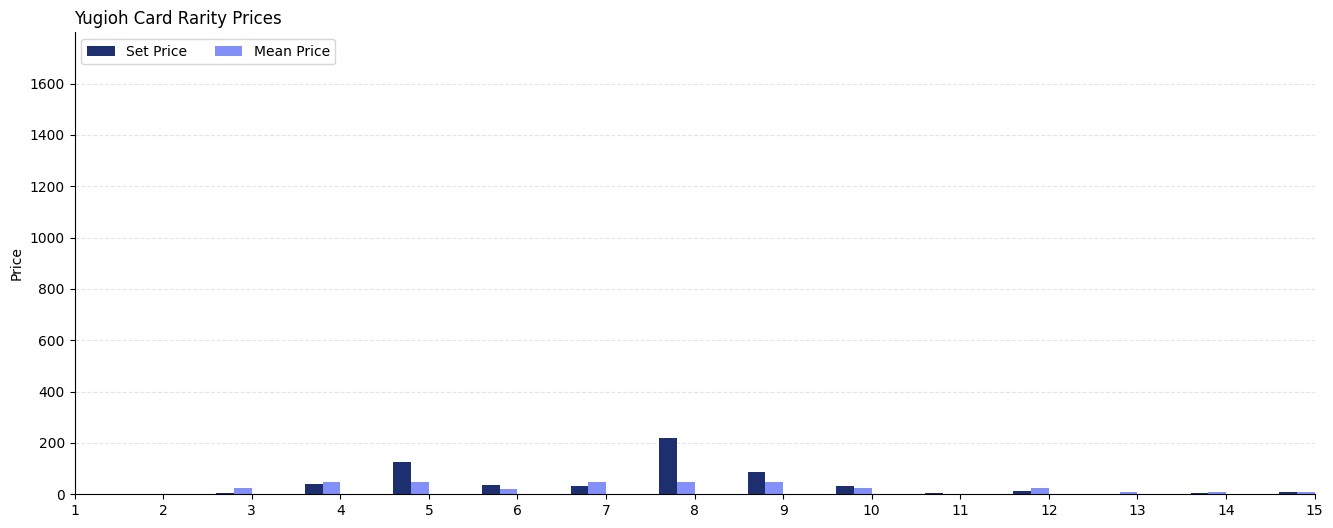

In [45]:
#Plot out average card price by rarity
# define figure
fig, ax = plt.subplots(1, figsize=(16, 6))# numerical x

x = np.arange(0, len(df_grouped.index))# plot bars
plt.bar(x - 0.3, df_grouped['card_sets_set_price'], width = 0.2, color = '#1D2F6F')
plt.bar(x - 0.1, df_grouped_mean['mean_card_set_price'], width = 0.2, color = '#8390FA')

# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# x y details
plt.ylabel('Price')
plt.xticks(x, df_grouped.index)
plt.xlim(1, 15)
# grid lines
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.2)# title and legend
plt.title('Yugioh Card Rarity Prices', loc ='left')
plt.legend(['Set Price','Mean Price'], loc='upper left', ncol = 2)
plt.show()

In [46]:
#Check missing data
df.isnull().values.any()

False

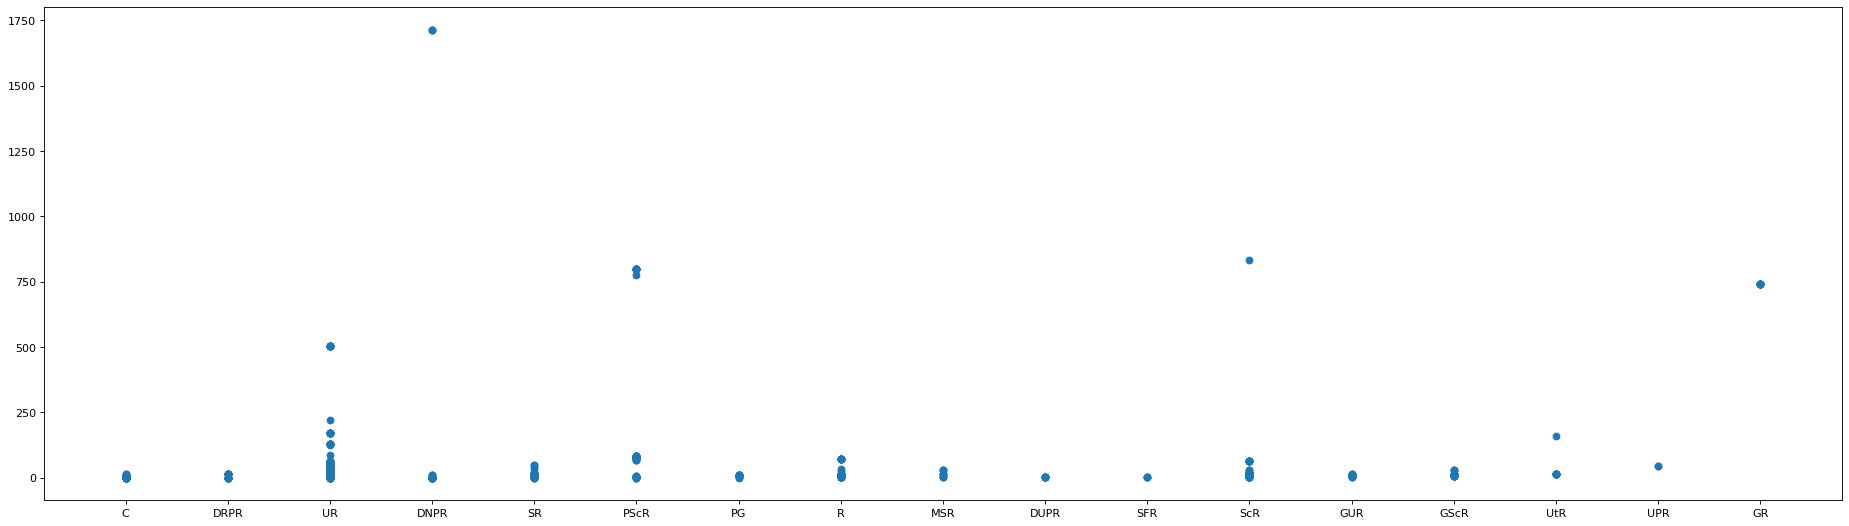

In [47]:
df = df.sort_values('card_sets_set_price')
plt.figure(figsize=(29, 8), dpi=80)
plt.scatter(df['card_sets_set_rarity_code'].astype(str),df['card_sets_set_price'])

In [48]:
df.dtypes

name                             object
type                             object
race                             object
card_sets_set_name               object
card_sets_set_code               object
card_sets_set_rarity_code        object
card_sets_set_price             float64
card_prices_cardmarket_price    float64
dtype: object

**What is K-Fold cross validation?** 

Cross-validation is a statistical method used to estimate the skill of machine learning models.
That k-fold cross validation is a procedure used to estimate the skill of the model on new data.
There are common tactics that you can use to select the value of k for your dataset.
There are commonly used variations on cross-validation such as stratified and repeated that are available in scikit-learn

Coefficients: 
 [[-39.28138378]]
Mean squared error: 2476.11
Coefficient of determination: -27956.59


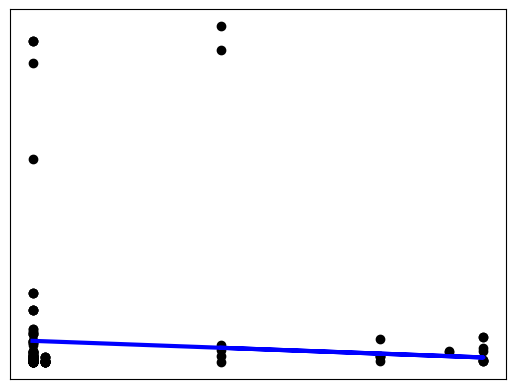

Coefficients: 
 [[-35.36369445]]
Mean squared error: 2928.71
Coefficient of determination: -28666.63


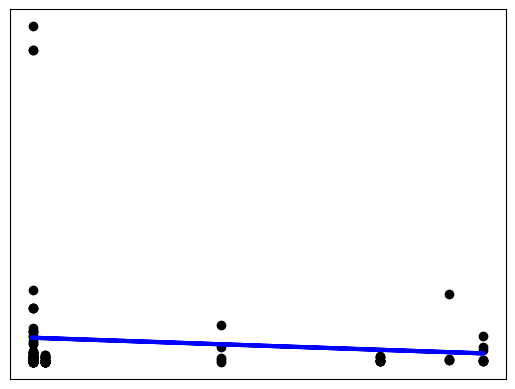

Coefficients: 
 [[-23.81762193]]
Mean squared error: 2102.10
Coefficient of determination: -18534.17


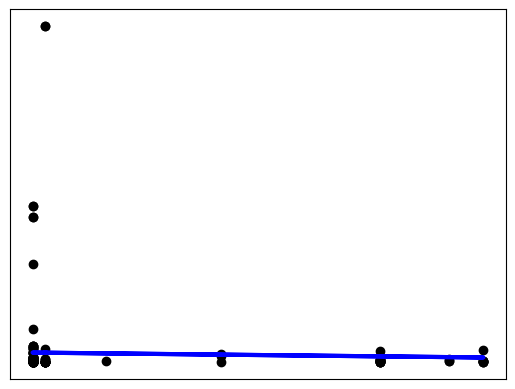

Coefficients: 
 [[-27.32426554]]
Mean squared error: 2311.11
Coefficient of determination: -19918.09


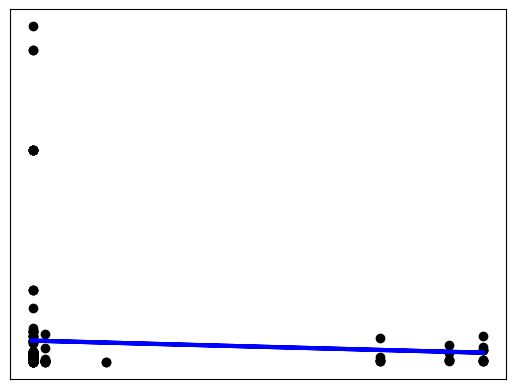

Coefficients: 
 [[-29.71063552]]
Mean squared error: 2394.42
Coefficient of determination: -24430.56


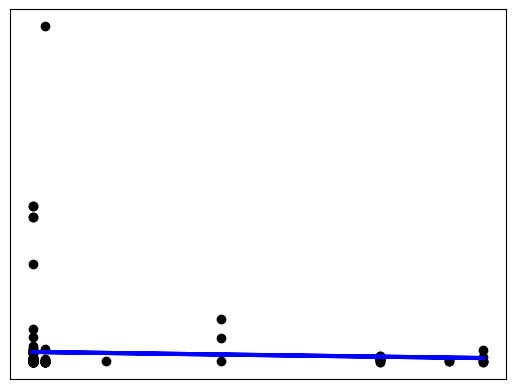

[-0.009066022669038665, -0.05351134580617534, 0.0017503534625805672, 0.00917315374484906, 0.003866078504809467]


In [51]:
#Identify measure values for predictions
X = pd.DataFrame(df['card_prices_cardmarket_price']).dropna()
y = pd.DataFrame(df['card_sets_set_price'])

model = LinearRegression()
scores = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train, test) in enumerate(kfold.split(X, y)):
    model.fit(X.iloc[train,:], y.iloc[train,:])
    score = model.score(X.iloc[test,:], y.iloc[test,:])
    x_pred=model.predict(X.iloc[test,:])
    scores.append(score)
    
    # The coefficients
    print("Coefficients: \n", model.coef_)
    # The mean squared error
    print("Mean squared error: %.2f" % mean_squared_error(X.iloc[test,:], x_pred))
    # The coefficient of determination: 1 is perfect prediction
    print("Coefficient of determination: %.2f" % r2_score(X.iloc[test,:], x_pred))

    # Plot outputs
    plt.scatter(X.iloc[test,:], y.iloc[test,:], color="black")
    plt.plot(X.iloc[test,:], x_pred, color="blue", linewidth=3)

    plt.xticks(())
    plt.yticks(())

    plt.show()
    
    #Check average score of fold
    test.mean()


print(scores)

In [52]:
#Generate random values
random_number_list=[]
for i in enumerate(range(0, len(X))):
    random_number = random.randrange(0, 10000)
    random_number_list.append(random_number)

In [53]:
#remove random variables to shorten the amount of data being read. Scale the model
X['Random']=random_number_list

# drop_first = True removes multi-collinearity
add_var = pd.get_dummies(X['Random'], prefix='Random', drop_first=True)
# Add all the columns to the model data
X = X.join(add_var)
# Drop the original column that was expanded
X.drop(columns=['Random'], inplace=True)
print(X.head())

     card_prices_cardmarket_price  Random_7  Random_52  Random_100  \
669                          0.05     False      False       False   
174                          0.02     False      False       False   
101                          0.02     False      False       False   
100                          0.02     False      False       False   
99                           0.02     False      False        True   

     Random_105  Random_112  Random_153  Random_156  Random_158  Random_161  \
669       False       False       False       False       False       False   
174       False       False        True       False       False       False   
101       False       False       False       False       False       False   
100       False       False       False       False       False       False   
99        False       False       False       False       False       False   

     ...  Random_9882  Random_9889  Random_9909  Random_9935  Random_9946  \
669  ...        False      

In [54]:
#Drop out random fields to align the shape of the df
y['Random']=random_number_list

# drop_first = True removes multi-collinearity
add_var = pd.get_dummies(y['Random'], prefix='Random', drop_first=True)
# Add all the columns to the model data
y = y.join(add_var)
# Drop the original column that was expanded
y.drop(columns=['Random'], inplace=True)
print(X.head())

     card_prices_cardmarket_price  Random_7  Random_52  Random_100  \
669                          0.05     False      False       False   
174                          0.02     False      False       False   
101                          0.02     False      False       False   
100                          0.02     False      False       False   
99                           0.02     False      False        True   

     Random_105  Random_112  Random_153  Random_156  Random_158  Random_161  \
669       False       False       False       False       False       False   
174       False       False        True       False       False       False   
101       False       False       False       False       False       False   
100       False       False       False       False       False       False   
99        False       False       False       False       False       False   

     ...  Random_9882  Random_9889  Random_9909  Random_9935  Random_9946  \
669  ...        False      

Coefficients: 
 [[-5.50227562e+00 -1.52100989e+00 -1.32676678e+00 ...  1.32984391e+01
   0.00000000e+00  3.49495758e-03]
 [-9.15175054e-15  1.00000000e+00 -6.84348411e-16 ... -8.04423802e-16
   0.00000000e+00 -6.52608393e-16]
 [ 4.26741975e-16  2.27465616e-16  1.00000000e+00 ...  5.72458747e-17
   0.00000000e+00 -1.87350135e-16]
 ...
 [ 2.08166817e-17  8.67361738e-18 -2.60208521e-18 ...  1.00000000e+00
   0.00000000e+00 -4.53196508e-17]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.95156391e-17 -7.37257477e-18  5.11743425e-17 ...  5.78963960e-17
   0.00000000e+00  1.00000000e+00]]
Mean squared error: 70819549384745492991180800.00
Coefficient of determination: -799620297722716355089661952.00


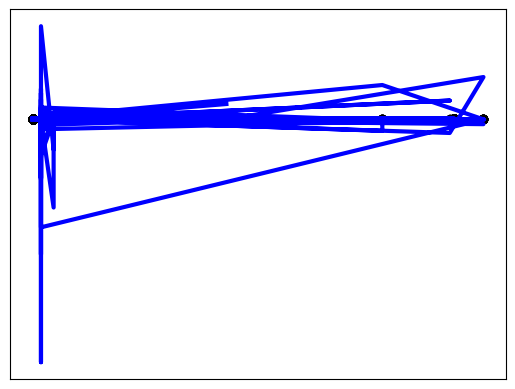

     card_prices_cardmarket_price  Random_7  Random_52  Random_100  \
101                          0.02     False      False       False   
97                           0.02     False      False       False   
96                           0.02     False      False       False   
84                           0.02     False      False       False   
16                           0.46     False      False       False   
..                            ...       ...        ...         ...   
18                           0.46     False      False       False   
390                          0.02     False      False       False   
398                          0.02     False      False       False   
397                          0.02     False      False       False   
19                           0.46     False      False       False   

     Random_105  Random_112  Random_153  Random_156  Random_158  Random_161  \
101       False       False       False       False       False       False   
9

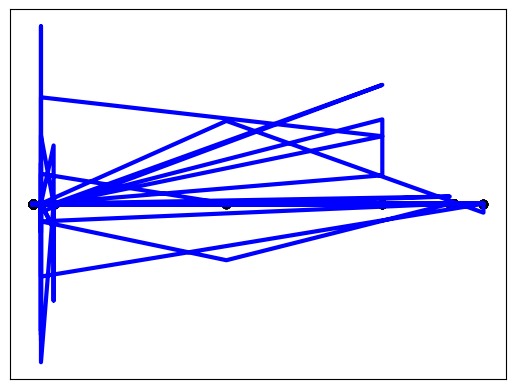

     card_prices_cardmarket_price  Random_7  Random_52  Random_100  \
98                           0.02     False      False       False   
95                           0.02     False      False       False   
89                           0.02     False      False       False   
553                          0.05     False      False       False   
584                          0.05     False      False       False   
..                            ...       ...        ...         ...   
647                          0.99     False      False       False   
381                          0.02     False      False       False   
156                          0.02     False      False       False   
162                          0.02     False      False       False   
393                          0.02     False      False       False   

     Random_105  Random_112  Random_153  Random_156  Random_158  Random_161  \
98        False       False       False        True       False       False   
9

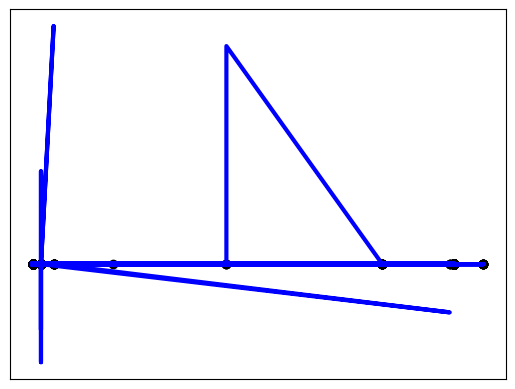

     card_prices_cardmarket_price  Random_7  Random_52  Random_100  \
669                          0.05     False      False       False   
100                          0.02     False      False       False   
496                          0.02     False      False       False   
497                          0.02     False      False       False   
92                           0.02     False      False       False   
..                            ...       ...        ...         ...   
157                          0.02     False      False       False   
392                          0.02     False      False       False   
394                          0.02     False      False       False   
520                          0.05     False      False       False   
521                          0.05     False      False       False   

     Random_105  Random_112  Random_153  Random_156  Random_158  Random_161  \
669       False       False       False       False       False       False   
1

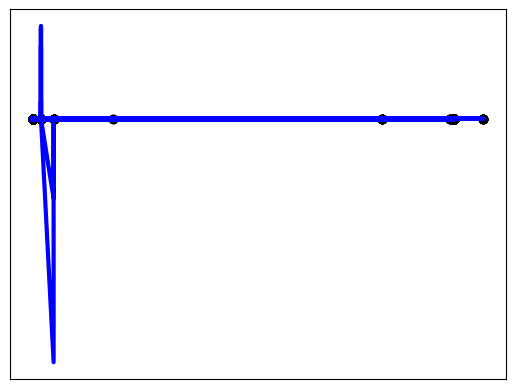

     card_prices_cardmarket_price  Random_7  Random_52  Random_100  \
494                          0.02     False      False       False   
495                          0.02      True      False       False   
91                           0.02     False      False       False   
90                           0.02     False      False       False   
552                          0.05     False      False       False   
..                            ...       ...        ...         ...   
255                          0.02     False      False       False   
262                          0.02     False      False       False   
163                          0.02     False      False       False   
158                          0.02     False      False       False   
395                          0.02     False      False       False   

     Random_105  Random_112  Random_153  Random_156  Random_158  Random_161  \
494       False       False       False       False       False       False   
4

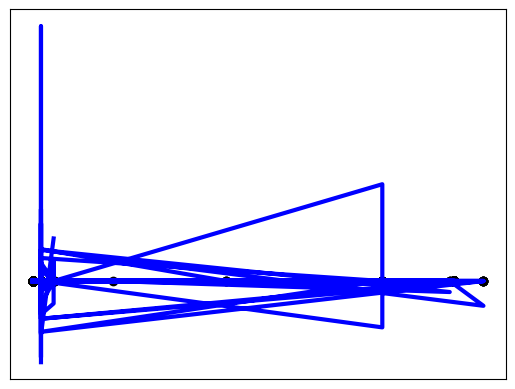

     card_prices_cardmarket_price  Random_7  Random_52  Random_100  \
174                          0.02     False      False       False   
99                           0.02     False      False        True   
94                           0.02     False      False       False   
93                           0.02     False      False       False   
87                           0.02     False      False       False   
..                            ...       ...        ...         ...   
164                          0.02     False      False       False   
160                          0.02     False      False       False   
391                          0.02     False      False       False   
396                          0.02     False      False       False   
519                          0.05     False      False       False   

     Random_105  Random_112  Random_153  Random_156  Random_158  Random_161  \
174       False       False        True       False       False       False   
9

In [56]:
scores = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train, test) in enumerate(kfold.split(X, y)):
    model.fit(X.iloc[train,:], y.iloc[train,:])
    score = model.score(X.iloc[test,:], y.iloc[test,:])
    x_pred=model.predict(X.iloc[test,:])
    #set prediction as a positive value
    scores.append(score)
    
    # The coefficients
    print("Coefficients: \n", model.coef_)
    # The mean squared error
    print("Mean squared error: %.2f" % mean_squared_error(X.iloc[test,:], x_pred))
    # The coefficient of determination: 1 is perfect prediction
    print("Coefficient of determination: %.2f" % r2_score(X.iloc[test,:], x_pred))
    

    # Plot outputs
    plt.scatter(X.iloc[test,:], y.iloc[test,:], color="black")
    plt.plot( X.iloc[test,:],x_pred, color="blue", linewidth=3)

    plt.xticks(())
    plt.yticks(())

    plt.show()
    
    #Check average score of fold
    print(X.iloc[test,:])
    print(x_pred)
    test.mean()

#Fold Scores
print(scores)


In [214]:
#The model is not a good fit needs more data